In [2]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Connect Google Drive if running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Set paths based on user description
base_dir = '/content/drive/MyDrive/ML_Safety'
test_dir = os.path.join(base_dir, 'test') # Adjust this if needed
models_dir = os.path.join(base_dir, 'models')

# Data transformations (adjust according to your training if needed)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class SafeImageFolder(datasets.ImageFolder):
    """Custom ImageFolder that ignores hidden directories like .hydra"""
    def find_classes(self, directory: str):
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir() and not entry.name.startswith('.'))
        if not classes:
            raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

# Load test data
test_dataset = SafeImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
def load_model(model_name, num_classes=1):
    """Loads the ResNet18 model."""
    # Use weights=None for newer torchvision versions
    model = torchvision.models.resnet18(weights=None)
    # Adjust final layer based on num_classes
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, num_classes)

    model_path = os.path.join(models_dir, model_name)
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

def evaluate_model(model, dataloader, device):
    """Evaluates the model and returns true labels and predicted probabilities."""
    model.to(device)
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Since num_classes=1, model outputs a single logit per image.
            # We use sigmoid to get probability of the positive class (class 1)
            probs_pos = torch.sigmoid(outputs).squeeze(1) # shape: [batch_size]

            # Construct a 2-class probability distribution: [prob_class_0, prob_class_1]
            probs_neg = 1.0 - probs_pos
            probs = torch.stack((probs_neg, probs_pos), dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_probs)

In [10]:
def compute_calibration(true_labels, pred_probs, num_bins=10):
    """Computes Expected Calibration Error (ECE) and bin statistics."""
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    confidences = np.max(pred_probs, axis=1)
    predictions = np.argmax(pred_probs, axis=1)
    accuracies = predictions == true_labels

    ece = 0.0
    bin_confs = []
    bin_accs = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()

            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

            bin_confs.append(avg_confidence_in_bin)
            bin_accs.append(accuracy_in_bin)
        else:
            bin_confs.append(0)
            bin_accs.append(0)

    return ece, bin_confs, bin_accs

def plot_reliability_diagram(bin_confs, bin_accs, model_name, ax):
    """Plots the reliability diagram."""
    ax.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='gray')
    ax.plot(bin_confs, bin_accs, marker='o', label=model_name, linewidth=2)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{model_name}')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.legend()
    ax.grid(True)

Evaluating pedestrian_resnet18.pth...
ECE for pedestrian_resnet18.pth: 0.4943
Evaluating traffic_light_resnet18.pth...
ECE for traffic_light_resnet18.pth: 0.8585
Evaluating vehicle_resnet18.pth...
ECE for vehicle_resnet18.pth: 0.3035


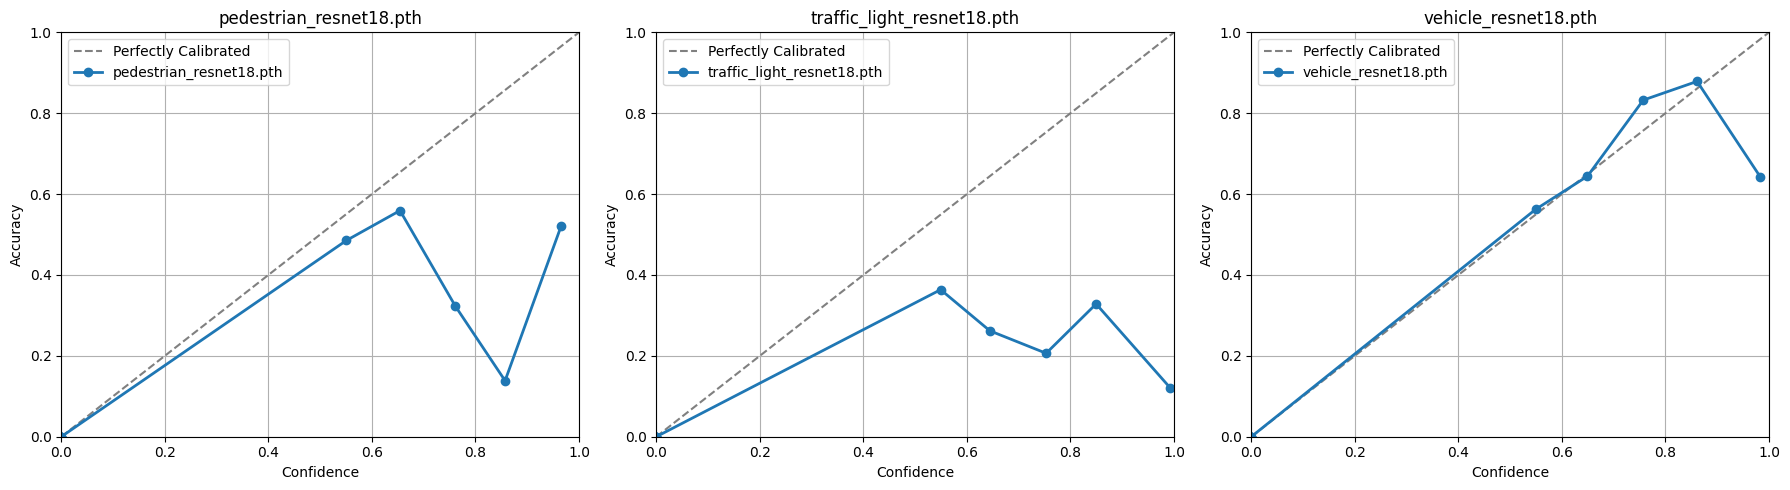

In [11]:
# Execution block for all 3 models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_names = ['pedestrian_resnet18.pth', 'traffic_light_resnet18.pth', 'vehicle_resnet18.pth']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model_name in enumerate(model_names):
    print(f"Evaluating {model_name}...")

    # Load model with 1 output node as defined in the checkpoint
    model = load_model(model_name, num_classes=1)

    true_labels, pred_probs = evaluate_model(model, test_loader, device)

    ece, bin_confs, bin_accs = compute_calibration(true_labels, pred_probs)
    print(f"ECE for {model_name}: {ece:.4f}")

    plot_reliability_diagram(bin_confs, bin_accs, model_name, axes[i])

plt.tight_layout()
plt.show()

In [16]:
# Set paths based on user description
base_dir = '/content/drive/MyDrive/ML_Safety'
test_dir = os.path.join(base_dir, 'test') # Adjust to 'test data' if needed
val_dir = os.path.join(base_dir, 'validation') # Adjust to 'validation data' if needed
models_dir = os.path.join(base_dir, 'models')

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class SafeImageFolder(datasets.ImageFolder):
    """Custom ImageFolder that ignores hidden directories like .hydra"""
    def find_classes(self, directory: str):
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir() and not entry.name.startswith('.'))
        if not classes:
            raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

# Load data
test_dataset = SafeImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

val_dataset = SafeImageFolder(root=val_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [17]:
def load_model(model_name, num_classes=1):
    """Loads the ResNet18 model."""
    model = torchvision.models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, num_classes)

    model_path = os.path.join(models_dir, model_name)
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

def get_logits_and_labels(model, dataloader, device):
    """Evaluates the model and returns true labels and raw logits."""
    model.to(device)
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            all_logits.extend(outputs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_logits)

In [18]:
def compute_calibration(true_labels, pred_probs, num_bins=10):
    """Computes Expected Calibration Error (ECE) and bin statistics."""
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    confidences = np.max(pred_probs, axis=1)
    predictions = np.argmax(pred_probs, axis=1)
    accuracies = predictions == true_labels

    ece = 0.0

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

def evaluate_nll(logits, labels, T):
    """Computes Negative Log-Likelihood (BCE) with Temperature Scaling."""
    import torch.nn.functional as F
    logits_tensor = torch.tensor(logits)
    labels_tensor = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    scaled_logits = logits_tensor / T
    nll = F.binary_cross_entropy_with_logits(scaled_logits, labels_tensor, reduction='mean')
    return nll.item()

def find_best_temperature(logits, labels):
    """Performs a line search to find the optimal Temperature T."""
    best_T = 1.0
    min_nll = float('inf')
    # Test values from 0.5 to 3.0 with step 0.1 (use round to avoid float precision issues)
    Ts = np.round(np.arange(0.5, 3.1, 0.1), 1)

    for T in Ts:
        nll = evaluate_nll(logits, labels, T)
        if nll < min_nll:
            min_nll = nll
            best_T = T

    return best_T

def get_probs(logits, T):
    """Applies Temperature scaling and returns probability distributions."""
    scaled_logits = torch.tensor(logits) / T
    probs_pos = torch.sigmoid(scaled_logits).squeeze(1).numpy()
    probs_neg = 1.0 - probs_pos
    return np.stack((probs_neg, probs_pos), axis=1)

In [19]:
# Execution block for Temperature Scaling
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_names = ['pedestrian_resnet18.pth', 'traffic_light_resnet18.pth', 'vehicle_resnet18.pth']

for model_name in model_names:
    print(f"--- Evaluating {model_name} ---")

    # Load model with 1 output node
    model = load_model(model_name, num_classes=1)

    # 1. Optimize T on the validation set
    print("Extracting validation logits...")
    val_labels, val_logits = get_logits_and_labels(model, val_loader, device)
    best_T = find_best_temperature(val_logits, val_labels)
    print(f"Optimal Temperature (T): {best_T:.2f}")

    # 2. Extract test logits and compute ECE before and after scaling
    print("Extracting test logits...")
    test_labels, test_logits = get_logits_and_labels(model, test_loader, device)

    # Before scaling (T = 1.0)
    probs_before = get_probs(test_logits, 1.0)
    ece_before = compute_calibration(test_labels, probs_before)

    # After scaling (T = best_T)
    probs_after = get_probs(test_logits, best_T)
    ece_after = compute_calibration(test_labels, probs_after)

    print(f"ECE before scaling (T=1.0): {ece_before:.4f}")
    print(f"ECE after scaling  (T={best_T:.2f}): {ece_after:.4f}\n")

--- Evaluating pedestrian_resnet18.pth ---
Extracting validation logits...
Optimal Temperature (T): 3.00
Extracting test logits...
ECE before scaling (T=1.0): 0.4943
ECE after scaling  (T=3.00): 0.3253

--- Evaluating traffic_light_resnet18.pth ---
Extracting validation logits...
Optimal Temperature (T): 3.00
Extracting test logits...
ECE before scaling (T=1.0): 0.8585
ECE after scaling  (T=3.00): 0.7332

--- Evaluating vehicle_resnet18.pth ---
Extracting validation logits...
Optimal Temperature (T): 3.00
Extracting test logits...
ECE before scaling (T=1.0): 0.3035
ECE after scaling  (T=3.00): 0.2968



In [20]:
# Cost-Optimal Decision for the pedestrian classifier
import pandas as pd
from IPython.display import display

model_name = 'pedestrian_resnet18.pth'
print(f"Evaluating Cost-Optimal Decision for {model_name}...\n")

# Load model
model = load_model(model_name, num_classes=1)

# Get validation logits to find best_T for this specific model
val_labels, val_logits = get_logits_and_labels(model, val_loader, device)
best_T = find_best_temperature(val_logits, val_labels)
print(f"Found Optimal T for {model_name}: {best_T:.2f}\n")

# Get test logits
test_labels, test_logits = get_logits_and_labels(model, test_loader, device)

# Function to calculate total loss
def calculate_total_loss(probs, labels, threshold):
    # Probability of positive class is index 1
    predictions = (probs[:, 1] >= threshold).astype(int)

    # False Negatives: True label is 1, prediction is 0
    fn = np.sum((labels == 1) & (predictions == 0))

    # False Positives: True label is 0, prediction is 1
    fp = np.sum((labels == 0) & (predictions == 1))

    # Given costs
    c_fn = 100
    c_fp = 1

    total_loss = c_fn * fn + c_fp * fp
    return total_loss, fn, fp

# Define probabilities
probs_uncalibrated = get_probs(test_logits, T=1.0)
probs_calibrated = get_probs(test_logits, T=best_T)

# Thresholds
tau_05 = 0.5
tau_opt = 0.0099

# Calculate losses
loss_uncal_05, fn_uncal_05, fp_uncal_05 = calculate_total_loss(probs_uncalibrated, test_labels, tau_05)
loss_uncal_opt, fn_uncal_opt, fp_uncal_opt = calculate_total_loss(probs_uncalibrated, test_labels, tau_opt)

loss_cal_05, fn_cal_05, fp_cal_05 = calculate_total_loss(probs_calibrated, test_labels, tau_05)
loss_cal_opt, fn_cal_opt, fp_cal_opt = calculate_total_loss(probs_calibrated, test_labels, tau_opt)

# Present results in a 2x2 table (Pandas DataFrame)
results = {
    "tau = 0.5": [loss_uncal_05, loss_cal_05],
    "tau = 0.0099 (tau*)": [loss_uncal_opt, loss_cal_opt]
}

df = pd.DataFrame(results, index=["Uncalibrated", "Temperature-Scaled"])
print("Total Loss Table:\n")
display(df)

# Identify the lowest loss
min_loss = df.values.min()
for row in df.index:
    for col in df.columns:
        if df.loc[row, col] == min_loss:
            print(f"\nThe combination with the lowest total loss is: {row} at {col} (Loss: {min_loss})")


Evaluating Cost-Optimal Decision for pedestrian_resnet18.pth...

Found Optimal T for pedestrian_resnet18.pth: 3.00

Total Loss Table:



,tau = 0.5,tau = 0.0099 (tau*)
Uncalibrated,360576,4925
Temperature-Scaled,360576,3599



The combination with the lowest total loss is: Temperature-Scaled at tau = 0.0099 (tau*) (Loss: 3599)


In [ ]:
## Exercise 7.7: Tracing Overconfidence Through the Safety Analysis

**1. Causal Scenario:**
The pedestrian classifier produces a **false negative yet reports high confidence**. Because the confidence is high, the planner registers "no pedestrian, reliable" and the low-confidence fallback (e.g., braking as a precaution) is not triggered. This leads directly to the Unsafe Control Action (UCA) where the vehicle fails to brake for a pedestrian.

**2. Safety Constraints:**
- **Model-level constraint:** The Expected Calibration Error (ECE) of the pedestrian classifier must be below a strictly defined threshold (e.g., $ECE < 0.05$) to ensure the confidence accurately reflects the likelihood of a false prediction.
- **System-level constraint:** The planner must utilize the cost-optimal decision threshold $\tau^* \approx 0.0099$ (instead of the default 0.5) when determining pedestrian presence, ensuring that the system is highly sensitive to the massive cost of a False Negative ($C_{FN}=100$). Furthermore, if the classifier's confidence falls below a certain threshold, the system must engage a safe fallback (e.g., automated braking).

**3. Verification:**
The model-level constraint is verified directly through the **Expected Calibration Error (ECE) evaluation** we performed on the in-distribution test set. By comparing the ECE before and after Temperature Scaling, we can provide evidence that the model has been calibrated and verify if the final ECE meets our predefined safety threshold.

**4. Residual Risk:**
Calibration *does not* eliminate false negatives; it merely ensures that the probabilities are honest. Even a perfectly calibrated model will still make incorrect predictions. Therefore, calibration alone cannot "close" the scenario. The **system-level fallback is absolutely still required** to safely handle those inevitable failures when they arise.